In [1]:
import pandas as pd
import seaborn as sns
# Load dataset
df = pd.read_csv("Credit_Card_Default.csv")

# Show first 5 rows
print(df.head())

# Shape
print("Shape:", df.shape)

# Columns
print(df.columns)

# Info
print(df.info())

   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default.payment.next.month  
0       0.0       0.0   

In [2]:
# Missing values
print(df.isnull().sum())

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64


In [3]:
print(df['default.payment.next.month'].value_counts())

default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64


In [4]:
# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [5]:
df.drop('ID', axis=1, inplace=True)

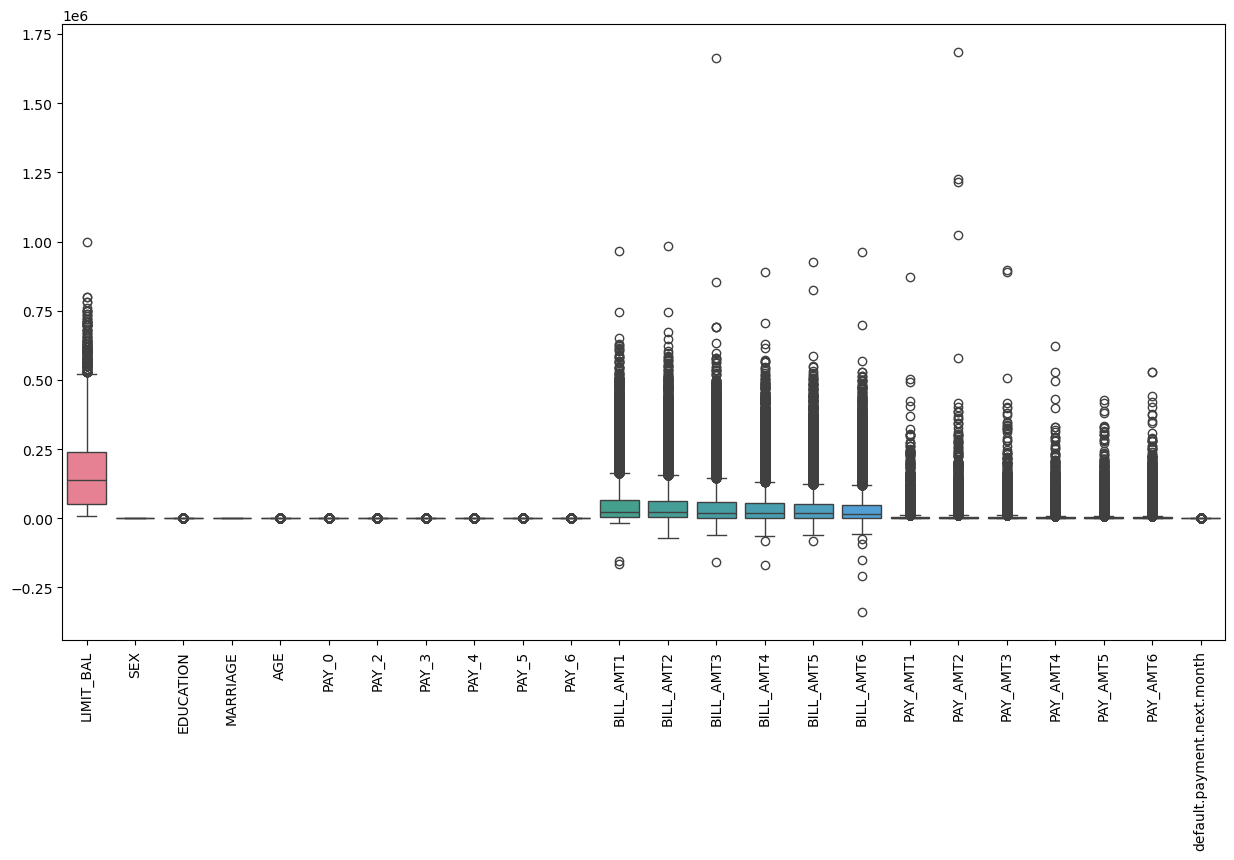

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,8))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [7]:
df.rename(columns={'default.payment.next.month':'Default'}, inplace=True)

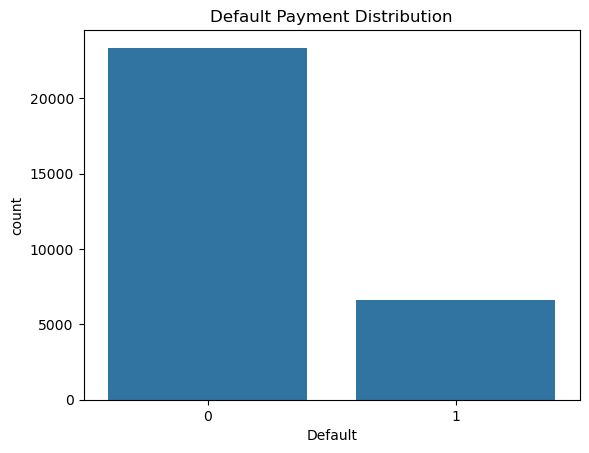

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Default', data=df)
plt.title("Default Payment Distribution")
plt.show()

In [9]:
print(df.columns)

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'Default'],
      dtype='object')


In [10]:
df.rename(columns={'default.payment.next.month':'Default'}, inplace=True)

In [11]:
print(df.columns.tolist())

['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'Default']


In [12]:
print(df.columns.tolist())

['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'Default']


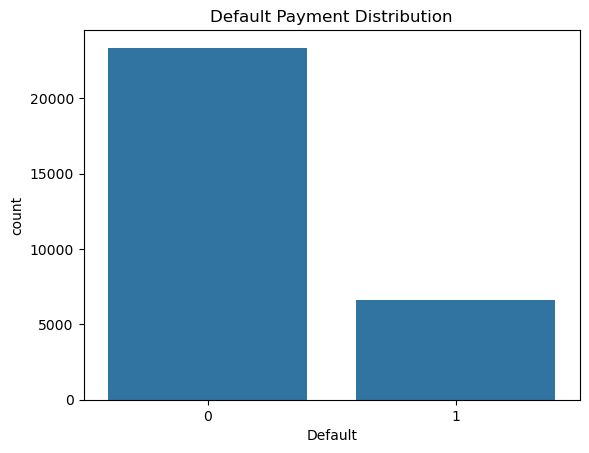

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Default', data=df)
plt.title("Default Payment Distribution")
plt.show()


In [14]:
# Features and target
X = df.drop('Default', axis=1)
y = df['Default']

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [18]:
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append([name, acc])
    print(f"\n{name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))

results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
print(results_df.sort_values(by="Accuracy", ascending=False))


Logistic Regression
Accuracy: 0.81
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4687
           1       0.69      0.24      0.35      1313

    accuracy                           0.81      6000
   macro avg       0.76      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000


Decision Tree
Accuracy: 0.72
              precision    recall  f1-score   support

           0       0.83      0.81      0.82      4687
           1       0.37      0.40      0.39      1313

    accuracy                           0.72      6000
   macro avg       0.60      0.61      0.60      6000
weighted avg       0.73      0.72      0.72      6000


Random Forest
Accuracy: 0.8138333333333333
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4687
           1       0.63      0.36      0.46      1313

    accuracy                           0.81      6000
   macro avg      

C:\Users\simra\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\simra\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\simra\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\simra\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^


KNN
Accuracy: 0.795
              precision    recall  f1-score   support

           0       0.84      0.92      0.87      4687
           1       0.55      0.36      0.43      1313

    accuracy                           0.80      6000
   macro avg       0.69      0.64      0.65      6000
weighted avg       0.77      0.80      0.78      6000


SVM
Accuracy: 0.8193333333333334
              precision    recall  f1-score   support

           0       0.84      0.96      0.89      4687
           1       0.68      0.33      0.45      1313

    accuracy                           0.82      6000
   macro avg       0.76      0.64      0.67      6000
weighted avg       0.80      0.82      0.79      6000


Naive Bayes
Accuracy: 0.707
              precision    recall  f1-score   support

           0       0.88      0.72      0.79      4687
           1       0.40      0.65      0.49      1313

    accuracy                           0.71      6000
   macro avg       0.64      0.69      0.64 

In [19]:
pip install tensorflow

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

ann = Sequential()

ann.add(Dense(units=16, activation='relu'))
ann.add(Dense(units=8, activation='relu'))
ann.add(Dense(units=1, activation='sigmoid'))

ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

ann.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8014 - loss: 0.4913
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8097 - loss: 0.4567
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8138 - loss: 0.4470
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8185 - loss: 0.4413
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8190 - loss: 0.4376
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8196 - loss: 0.4346
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8207 - loss: 0.4323
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8214 - loss: 0.4315
Epoch 9/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8212 - loss: 0.4308
Epoch 10/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8201 - loss: 0.4299
Epoch 11/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8215 - loss: 0.4292
Epoch 12/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/ste

In [21]:
loss, acc = ann.evaluate(X_test, y_test)
print("ANN Accuracy:", acc)

188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8172 - loss: 0.4353    
ANN Accuracy: 0.8171666860580444


In [22]:
results.append(["ANN", acc])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
print(results_df.sort_values(by="Accuracy", ascending=False))

                 Model  Accuracy
4                  SVM  0.819333
6                  ANN  0.817167
2        Random Forest  0.813833
0  Logistic Regression  0.810000
3                  KNN  0.795000
1        Decision Tree  0.720000
5          Naive Bayes  0.707000


In [23]:
print(df.skew())

LIMIT_BAL     0.992867
SEX          -0.424183
EDUCATION     0.970972
MARRIAGE     -0.018742
AGE           0.732246
PAY_0         0.731975
PAY_2         0.790565
PAY_3         0.840682
PAY_4         0.999629
PAY_5         1.008197
PAY_6         0.948029
BILL_AMT1     2.663861
BILL_AMT2     2.705221
BILL_AMT3     3.087830
BILL_AMT4     2.821965
BILL_AMT5     2.876380
BILL_AMT6     2.846645
PAY_AMT1     14.668364
PAY_AMT2     30.453817
PAY_AMT3     17.216635
PAY_AMT4     12.904985
PAY_AMT5     11.127417
PAY_AMT6     10.640727
Default       1.343504
dtype: float64


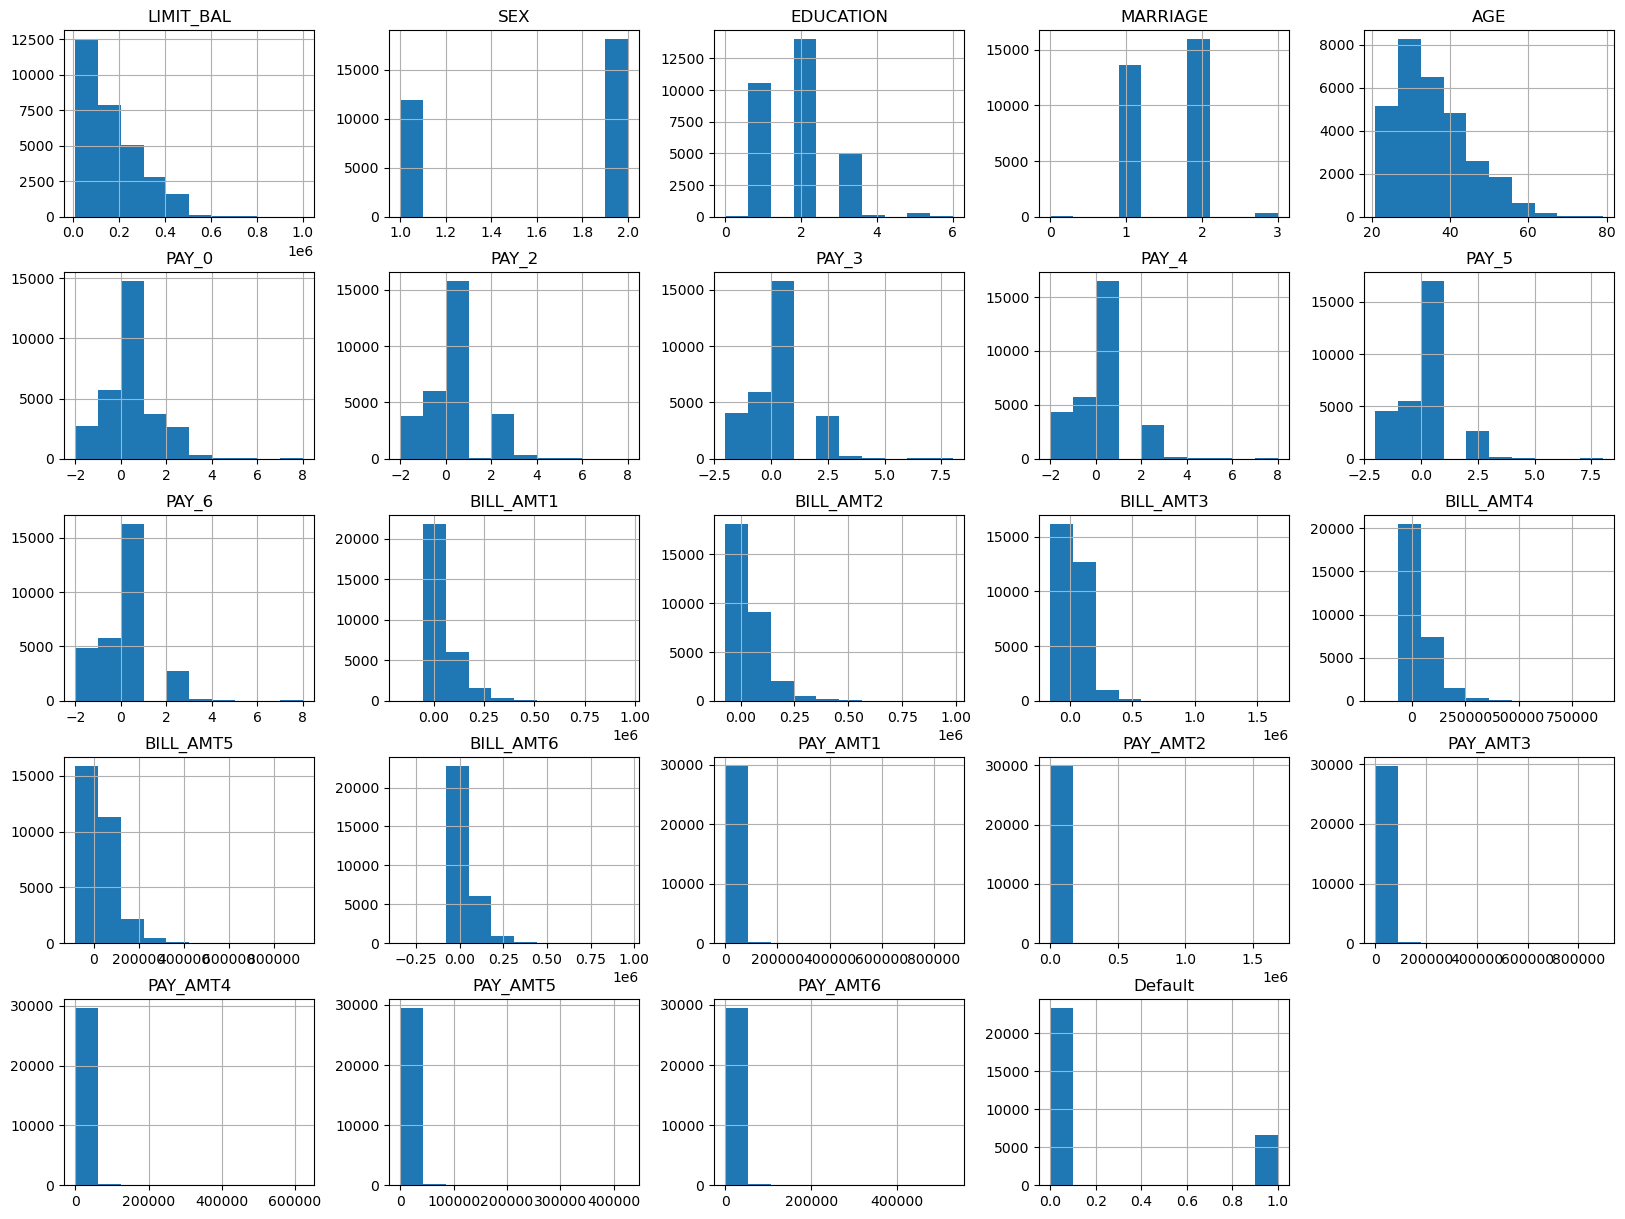

In [24]:
import matplotlib.pyplot as plt
df.hist(figsize=(20,15))
plt.show()

In [25]:
import numpy as np

skewed_cols = ['BILL_AMT1','BILL_AMT2','BILL_AMT3',
               'BILL_AMT4','BILL_AMT5','BILL_AMT6',
               'PAY_AMT1','PAY_AMT2','PAY_AMT3',
               'PAY_AMT4','PAY_AMT5','PAY_AMT6']

for col in skewed_cols:
    df[col] = np.log1p(df[col])

C:\Users\simra\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\simra\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [26]:
print(df[skewed_cols].skew())

BILL_AMT1         NaN
BILL_AMT2         NaN
BILL_AMT3         NaN
BILL_AMT4         NaN
BILL_AMT5         NaN
BILL_AMT6         NaN
PAY_AMT1    -1.292375
PAY_AMT2    -1.239832
PAY_AMT3    -1.079249
PAY_AMT4    -0.966038
PAY_AMT5    -0.938329
PAY_AMT6    -0.854558
dtype: float64


C:\Users\simra\anaconda3\Lib\site-packages\pandas\core\nanops.py:1256: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean


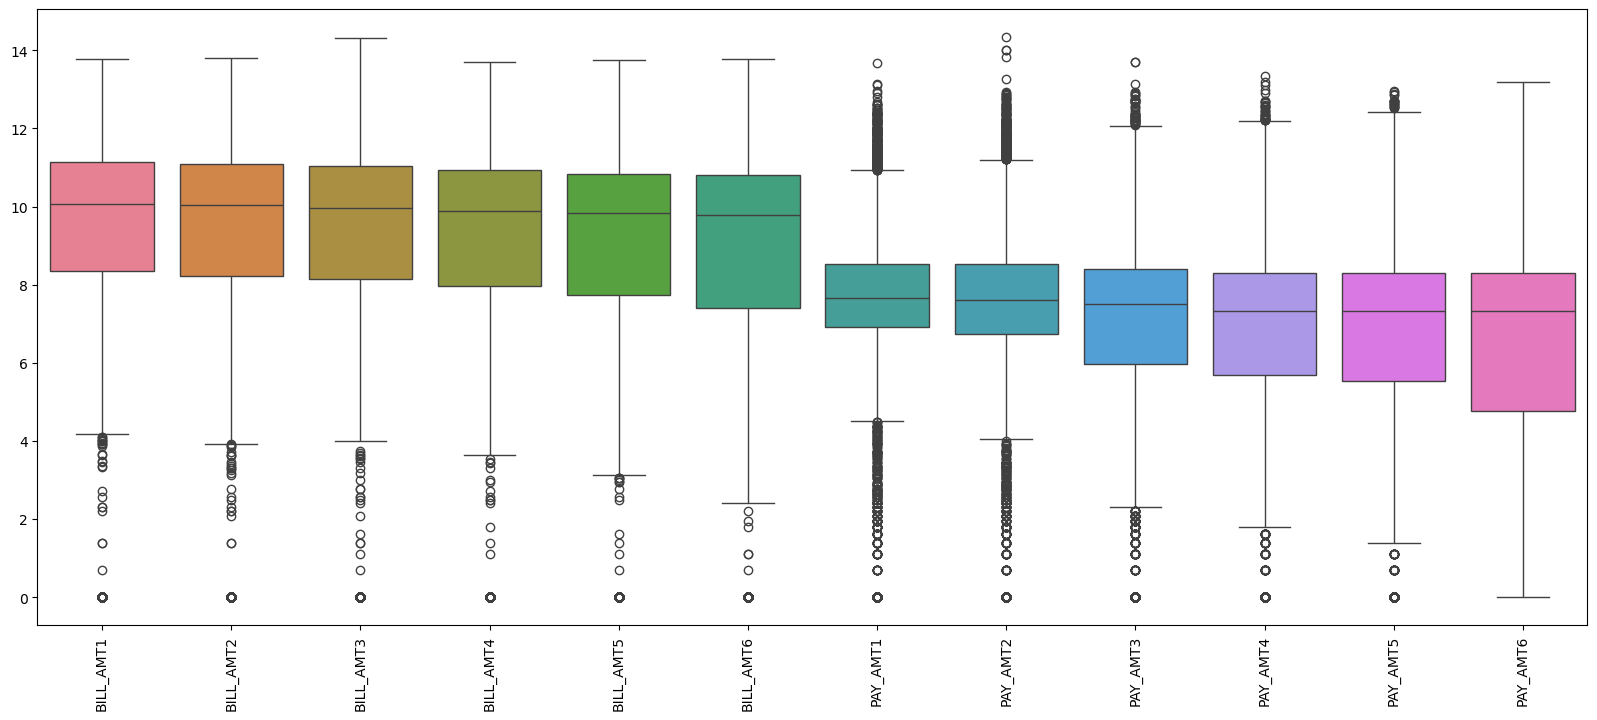

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20,8))
sns.boxplot(data=df[skewed_cols])
plt.xticks(rotation=90)
plt.show()

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
from sklearn.preprocessing import MinMaxScaler

mm = MinMaxScaler()
X_train_norm = mm.fit_transform(X_train)
X_test_norm = mm.transform(X_test)

In [30]:
# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ---------------- SVM Hyperparameter Tuning ----------------
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid_svm = {
    'C': [1, 10],              # reduced
    'kernel': ['rbf']          # only best-performing kernel usually
}

grid = GridSearchCV(SVC(), param_grid_svm, cv=2, n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print("Best SVM Parameters:", grid.best_params_)
print("Best SVM Score:", grid.best_score_)


# ---------------- Random Forest Hyperparameter Tuning ----------------
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    'n_estimators': [100, 200],   # reduced
    'max_depth': [10, None]       # reduced
}

grid_rf = GridSearchCV(RandomForestClassifier(), param_grid_rf, cv=2, n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("Best RF Parameters:", grid_rf.best_params_)
print("Best RF Score:", grid_rf.best_score_)

Best SVM Parameters: {'C': 1, 'kernel': 'rbf'}
Best SVM Score: 0.818875
Best RF Parameters: {'max_depth': 10, 'n_estimators': 200}
Best RF Score: 0.8195


In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],   
    'max_depth': [10, None]     
}

grid_rf = GridSearchCV(RandomForestClassifier(), param_grid, cv=2, n_jobs=-1)
grid_rf.fit(X_train, y_train)

print(grid_rf.best_params_)
print(grid_rf.best_score_)

{'max_depth': 10, 'n_estimators': 200}
0.8194583333333334


In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

ann = Sequential()

ann.add(Dense(64, activation='relu'))
ann.add(Dropout(0.2))

ann.add(Dense(32, activation='relu'))
ann.add(Dropout(0.2))

ann.add(Dense(16, activation='relu'))

ann.add(Dense(1, activation='sigmoid'))

ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

ann.fit(X_train_scaled, y_train, epochs=50, batch_size=32)

Epoch 1/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8013 - loss: 0.4846
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8132 - loss: 0.4537
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8157 - loss: 0.4458
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8170 - loss: 0.4417
Epoch 5/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8173 - loss: 0.4395
Epoch 6/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8175 - loss: 0.4379
Epoch 7/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8185 - loss: 0.4358
Epoch 8/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8188 - loss: 0.4338
Epoch 9/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8182 - loss: 0.4337
Epoch 10/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8189 - loss: 0.4315
Epoch 11/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8196 - loss: 0.4304
Epoch 12/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

ann = Sequential()

ann.add(Dense(128, activation='relu', input_dim=X_train_scaled.shape[1]))
ann.add(Dropout(0.2))

ann.add(Dense(64, activation='relu'))
ann.add(Dropout(0.2))

ann.add(Dense(32, activation='relu'))

ann.add(Dense(1, activation='sigmoid'))

ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = ann.fit(X_train_scaled, y_train, epochs=30, batch_size=64, validation_split=0.2)

C:\Users\simra\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.8037 - loss: 0.4820 - val_accuracy: 0.8135 - val_loss: 0.4593
Epoch 2/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8157 - loss: 0.4505 - val_accuracy: 0.8133 - val_loss: 0.4503
Epoch 3/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8169 - loss: 0.4414 - val_accuracy: 0.8190 - val_loss: 0.4449
Epoch 4/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8186 - loss: 0.4387 - val_accuracy: 0.8125 - val_loss: 0.4467
Epoch 5/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8204 - loss: 0.4353 - val_accuracy: 0.8206 - val_loss: 0.4420
Epoch 6/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8209 - loss: 0.4333 - val_accuracy: 0.8163 - val_loss: 0.4435
Epoch 7/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8205 - loss: 0.4312 - val_accuracy: 0.8179 - val_loss: 0.4408
Epoch 8/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8201 - loss: 0.4299 - val_acc

In [34]:
df['BILL_TOTAL'] = df[['BILL_AMT1','BILL_AMT2','BILL_AMT3']].sum(axis=1)
df['PAY_TOTAL'] = df[['PAY_AMT1','PAY_AMT2','PAY_AMT3']].sum(axis=1)

In [35]:
from xgboost import XGBClassifier

xgb = XGBClassifier()
xgb.fit(X_train, y_train)
print(xgb.score(X_test, y_test))

0.8148333333333333


In [36]:
# Split again
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train XGBoost
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb.fit(X_train, y_train)

print("XGB Accuracy:", xgb.score(X_test, y_test))

XGB Accuracy: 0.8215


In [37]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

# Function to store metrics
def evaluate_model(name, y_train, train_pred, y_test, test_pred):
    results.append({
        'Model': name,
        'Train Accuracy': accuracy_score(y_train, train_pred),
        'Test Accuracy': accuracy_score(y_test, test_pred),
        'Precision': precision_score(y_test, test_pred),
        'Recall': recall_score(y_test, test_pred),
        'F1 Score': f1_score(y_test, test_pred)
    })

# ---------------- SVM ----------------
best_svm = SVC(C=1, kernel='rbf')
best_svm.fit(X_train_scaled, y_train)

svm_train_pred = best_svm.predict(X_train_scaled)
svm_test_pred = best_svm.predict(X_test_scaled)

evaluate_model("SVM", y_train, svm_train_pred, y_test, svm_test_pred)


# ---------------- Random Forest ----------------
best_rf = RandomForestClassifier(n_estimators=200, max_depth=10)
best_rf.fit(X_train, y_train)

rf_train_pred = best_rf.predict(X_train)
rf_test_pred = best_rf.predict(X_test)

evaluate_model("Random Forest", y_train, rf_train_pred, y_test, rf_test_pred)


# ---------------- XGBoost ----------------
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb.fit(X_train, y_train)

xgb_train_pred = xgb.predict(X_train)
xgb_test_pred = xgb.predict(X_test)

evaluate_model("XGBoost", y_train, xgb_train_pred, y_test, xgb_test_pred)


# Final Comparison Table
comparison_df = pd.DataFrame(results)
print(comparison_df)

           Model  Train Accuracy  Test Accuracy  Precision    Recall  F1 Score
0            SVM        0.825292       0.819333   0.678072  0.332064  0.445808
1  Random Forest        0.856792       0.821000   0.671942  0.355674  0.465139
2        XGBoost        0.832458       0.821500   0.668994  0.364813  0.472154
